In [ ]:
!pip install datasets transformers comet_ml --quiet
from datasets import load_dataset
from transformers import AutoTokenizer
import numpy as np
import matplotlib.pyplot as plt
import math
import os
from google.colab import userdata
from tqdm import tqdm
import sys

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 782.3/782.3 kB 14.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 33.4 MB/s eta 0:00:00


In [ ]:
USE_COMET = True  # Set True if you want logging
if USE_COMET:
    from comet_ml import Experiment
    if 'google.colab' in sys.modules:
        experiment = Experiment(userdata.get('COMET_KEY'))
    else:
        experiment = None
else:
    experiment = None

!pip install torch
from torch.utils.data import DataLoader, Dataset
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim

COMET WARNING: To get all data logged automatically, import comet_ml before the following modules: sklearn, torch.
COMET WARNING: As you are running in a Jupyter environment, you will need to call `experiment.end()` when finished to ensure all metrics and code are logged before exiting.
COMET INFO: Experiment is live on comet.com https://www.comet.com/irsotarriva/general/224360fe3abc4a5e8e6455bc3d7b1875

COMET INFO: Couldn't find a Git repository in '/content' nor in any parent directory. Set `COMET_GIT_DIRECTORY` if your Git Repository is elsewhere.


In [ ]:
tokenizer = AutoTokenizer.from_pretrained("gpt2")
tokenizer.pad_token = tokenizer.eos_token

MAX_LEN = 128

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/665 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/1.04M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F


# ---------------------------
# Sparse MLP block (light version)
# ---------------------------

class SparseMLP(nn.Module):
    """
    Light conditional sparsity:
    - Large hidden dimension
    - Only top-k activations kept
    """

    def __init__(self, dim, hidden_dims, outdim, topk_ratio=0.25):
        super().__init__()
        self.fcs = nn.ModuleList()
        fc1 = nn.Linear(dim, hidden_dims[0])
        self.fcs.append(fc1)
        for i in range(len(hidden_dims)-1):
            self.fcs.append(nn.Linear(hidden_dims[i], hidden_dims[i+1]))
        fc2 = nn.Linear(hidden_dims[-1], outdim)
        self.fcs.append(fc2)
        self.topk_ratio = topk_ratio

    def forward(self, x):
        for fc in self.fcs:
            x = F.gelu(fc(x))
            k = max(1, int(x.size(-1) * self.topk_ratio))
            topk_vals, _ = torch.topk(x, k, dim=-1)
            threshold = topk_vals[:, -1].unsqueeze(-1)
            x = x * (x >= threshold).float()
        return x

# ---------------------------
# Single Speed Transition F_k
# ---------------------------

class SpeedTransition(nn.Module):
    def __init__(self, state_dim, input_dim, hidden_layers):
        super().__init__()

        # input = S_k, x_k, S_k+1, stale_flag
        total_in = state_dim + input_dim + state_dim + 1

        self.mlp = SparseMLP(total_in, hidden_dims=hidden_layers, outdim=state_dim)

        self.norm = nn.LayerNorm(state_dim)

    def forward(self, S_k, x_k, S_kplus1, stale_flag):
        """
        S_k:        (B, D)
        x_k:        (B, D_in)
        S_kplus1:   (B, D)
        stale_flag: (B, 1)
        """

        inp = torch.cat([S_k, x_k, S_kplus1, stale_flag], dim=-1)
        delta = self.mlp(inp)

        # residual update
        S_new = S_k + delta

        # optional normalization to help stability
        S_new = self.norm(S_new)

        return S_new


# ---------------------------
# Hierarchical Multi-Speed Model
# ---------------------------

class MultiSpeedRNN(nn.Module):
    def __init__(
        self,
        vocab_size,
        state_dim=256,
        num_levels=5,  # levels 0..K-1 (block sizes 1,2,4,...)
        hidden_layers=[1024],
        head_layers = [16],
        topk_ratio=0.25,
        head_topk_ratio=0.25
    ):
        super().__init__()

        self.num_levels = num_levels
        self.state_dim = state_dim

        self.embedding = nn.Embedding(vocab_size, state_dim)

        # transitions per level
        self.transitions = nn.ModuleList([
            SpeedTransition(state_dim, state_dim, hidden_layers)
            for _ in range(num_levels)
        ])

        # prediction head sees all levels. MLP with sparse activations and multiple layers indicated by head_layers
        self.head = SparseMLP(state_dim * num_levels, head_layers, vocab_size, topk_ratio=head_topk_ratio)

    def init_states(self, batch_size, device):
        """
        Initializes hidden states for all levels to zeros.
        Returns a list of tensors, one per level, each of shape (B, D).
        """
        return [torch.ones(batch_size, self.state_dim, device=device) for _ in range(self.num_levels)]


    def get_init_state(self, batch_size, device):
        """
        Returns a state dict for inference, with all buffers and hidden states initialized.
        """
        states = self.init_states(batch_size, device)
        buffers = [[] for _ in range(self.num_levels)]
        return {'states': states, 'buffers': buffers}

    def forward_train(self, tokens):
        """
        Training forward: processes a full sequence, returns loss (cross-entropy over all steps + stability loss).
        tokens: (B, T)
        """
        B, T = tokens.shape
        device = tokens.device

        states = self.init_states(B, device)
        buffers = [[] for _ in range(self.num_levels)]
        logits_seq = []
        stability_losses = []

        for t in range(T):
            x = self.embedding(tokens[:, t])  # (B, D)
            buffers[0].append(x)
            for level in range(self.num_levels):
                block_size = 2 ** level
                if len(buffers[level]) == block_size:
                    x_k = torch.stack(buffers[level], dim=0).mean(dim=0)
                    buffers[level] = []
                    if level + 1 < self.num_levels:
                        buffers[level + 1].append(x_k)
                    if level + 1 < self.num_levels:
                        higher_updated = (len(buffers[level + 1]) == 0)
                        stale_flag = torch.zeros(B, 1, device=device)
                        if not higher_updated:
                            stale_flag += 1.0
                    else:
                        stale_flag = torch.zeros(B, 1, device=device)
                    S_k = states[level]
                    S_kplus1 = (
                        states[level + 1]
                        if level + 1 < self.num_levels
                        else torch.zeros_like(S_k)
                    )
                    states[level] = self.transitions[level](S_k, x_k, S_kplus1, stale_flag)
                    target_norm = torch.norm(torch.ones_like(states[level]), dim=-1)
                    current_norm = torch.norm(states[level], dim=-1)
                    stability_losses.append(((current_norm - target_norm) ** 2).mean())
            concat_state = torch.cat(states, dim=-1)
            logits = self.head(concat_state)
            logits_seq.append(logits)

        logits_seq = torch.stack(logits_seq, dim=1)  # (B, T, vocab)
        # Average cross-entropy loss over all steps except first (predict next token)
        pred = logits_seq[:, :-1, :].reshape(-1, logits_seq.size(-1))
        target = tokens[:, 1:].reshape(-1)
        ce_loss = F.cross_entropy(pred, target)
        ce_loss = ce_loss / (T - 1)
        if stability_losses:
            stability_loss = torch.stack(stability_losses).mean()
        else:
            stability_loss = torch.tensor(0.0, device=device)
        return ce_loss, stability_loss

    def forward(self, tokens, state):
        """
        Inference forward: processes a single step (tokens: (B,) or (B, 1)),
        state: dict containing all necessary state (buffers, hidden states, counters).
        Returns logits, new_state.
        """
        # Unpack state
        states = state['states']  # list of tensors, len=num_levels, each (B, D)
        buffers = state['buffers']  # list of lists, len=num_levels, each list of (B, D)
        device = tokens.device
        B = tokens.shape[0]

        # Squeeze if tokens are (B, 1), otherwise assume (B,)
        if tokens.dim() == 2:
            tokens = tokens.squeeze(1)  # (B, 1) -> (B,)

        # Embed current token
        x = self.embedding(tokens)  # (B, D)
        buffers[0].append(x)

        for level in range(self.num_levels):
            block_size = 2 ** level
            if len(buffers[level]) == block_size:
                x_k = torch.stack(buffers[level], dim=0).mean(dim=0)
                buffers[level] = []
                if level + 1 < self.num_levels:
                    buffers[level + 1].append(x_k)
                if level + 1 < self.num_levels:
                    higher_updated = (len(buffers[level + 1]) == 0)
                    stale_flag = torch.zeros(B, 1, device=device)
                    if not higher_updated:
                        stale_flag += 1.0
                else:
                    stale_flag = torch.zeros(B, 1, device=device)
                S_k = states[level]
                S_kplus1 = (
                    states[level + 1]
                    if level + 1 < self.num_levels
                    else torch.zeros_like(S_k)
                )
                states[level] = self.transitions[level](S_k, x_k, S_kplus1, stale_flag)

        concat_state = torch.cat(states, dim=-1)
        logits = self.head(concat_state)

        # Package new state
        new_state = {
            'states': states,
            'buffers': buffers
        }
        return logits, new_state

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = MultiSpeedRNN(
    vocab_size=tokenizer.vocab_size,
    state_dim=128,
    num_levels=6,
    hidden_layers=[128,256,128],
    head_layers=[256,256],
    head_topk_ratio=0.25,
    topk_ratio=0.10
).to(device)

optimizer = optim.Adam(model.parameters(), lr=3e-4)
#estimate the total number of parameters in the model and print a summary of the model architecture and parameters on each section of the model (embedding, transitions, head)
total_params = sum(p.numel() for p in model.parameters())
print(f"Total parameters: {total_params}")
print("Model architecture and parameters:")
print(f"Embedding: {sum(p.numel() for p in model.embedding.parameters())} parameters")
for i, transition in enumerate(model.transitions):
    transition_params = sum(p.numel() for p in transition.parameters())
    print(f"Transition level {i}: {transition_params} parameters")
print(f"Head: {sum(p.numel() for p in model.head.parameters())} parameters")

Total parameters: 20404177
Model architecture and parameters:
Embedding: 6432896 parameters
Transition level 0: 132096 parameters
Transition level 1: 132096 parameters
Transition level 2: 132096 parameters
Transition level 3: 132096 parameters
Transition level 4: 132096 parameters
Transition level 5: 132096 parameters
Head: 13178705 parameters


In [ ]:
ds = load_dataset("roneneldan/TinyStories", streaming=True)

# For streaming datasets, we use take() and skip() to split
# Let's use 10k samples for validation, rest for training
VAL_SIZE = 1000

train_stream = ds["train"].skip(VAL_SIZE)
val_stream = ds["train"].take(VAL_SIZE)

def tokenize_function(examples):
    """Tokenize a batch of texts"""
    encodings = tokenizer(
        examples["text"],
        truncation=True,
        padding="max_length",
        max_length=MAX_LEN,
    )
    return {"input_ids": encodings["input_ids"]}

# Apply tokenization to streams
train_stream = train_stream.map(tokenize_function, batched=True)
val_stream = val_stream.map(tokenize_function, batched=True)

# Set format to return PyTorch tensors
train_stream = train_stream.with_format("torch")
val_stream = val_stream.with_format("torch")

BATCH_SIZE = 256

# For streaming datasets, we can't shuffle in DataLoader, so shuffle in the stream
train_stream = train_stream.shuffle(buffer_size=10_000, seed=42)

# Create dataloaders - note we can't use shuffle=True with IterableDataset
from torch.utils.data import IterableDataset

class StreamDataset(IterableDataset):
    def __init__(self, stream):
        self.stream = stream

    def __iter__(self):
        for item in self.stream:
            yield item["input_ids"]

train_dataset = StreamDataset(train_stream)
val_dataset = StreamDataset(val_stream)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE)

README.md: 0.00B [00:00, ?B/s]

In [ ]:
# Checkpoint configuration
checkpoint_path = "checkpoint.pt"
start_epoch = 0

train_losses = []
val_losses = []
step_train_losses = []

# Resume from checkpoint if it exists
if os.path.exists(checkpoint_path):
    checkpoint = torch.load(checkpoint_path, map_location=device)
    model.load_state_dict(checkpoint["model_state_dict"])
    optimizer.load_state_dict(checkpoint["optimizer_state_dict"])
    start_epoch = checkpoint["epoch"] + 1
    train_losses = checkpoint.get("train_losses", [])
    val_losses = checkpoint.get("val_losses", [])
    print(f"Resuming training from epoch {start_epoch+1}")

EPOCHS = 50
STEPS_PER_EPOCH = int(2000000/BATCH_SIZE)  # Since streaming has unknown length, train for fixed steps
VAL_STEPS = 100  # Number of validation batches
logStep = 0
EPOCHS_UNTIL_MAX_LEN = 10 #number of epochs before the curriculum scheduler shows the text up to MAX_LEN
vocab_size = tokenizer.vocab_size

if experiment:
    experiment.log_parameters({
        "state_dim": model.state_dim,
        "num_levels": model.num_levels,
        "batch_size": BATCH_SIZE,
        "max_len": MAX_LEN,
        "epochs": EPOCHS,
        "steps_per_epoch": STEPS_PER_EPOCH,
        "optimizer": "Adam",
        "lr": 3e-4,
    })

for epoch in range(start_epoch, EPOCHS):
    model.train()
    epoch_loss = 0.0

    # Create iterator for this epoch
    train_iter = iter(train_loader)

    progress_bar = tqdm(range(STEPS_PER_EPOCH), desc=f"Epoch {epoch+1}")

    for step in progress_bar:
        try:
            batch = next(train_iter)
        except StopIteration:
            # If we run out of data, create a new iterator
            train_iter = iter(train_loader)
            batch = next(train_iter)

        batch = batch.to(device)

        # Optional: curriculum learning on sequence length
        scheduled_len = int(1 + ((MAX_LEN - 2) * logStep / (STEPS_PER_EPOCH*EPOCHS_UNTIL_MAX_LEN)))
        seq_len = max(2, min(MAX_LEN, scheduled_len))
        cropped_batch = batch[:, :seq_len]

        optimizer.zero_grad()

        # Forward pass - use forward_train for training (returns loss directly)
        ce_loss, stability_loss = model.forward_train(cropped_batch)

        loss = ce_loss + 0.01 * stability_loss
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()

        # Track metrics
        epoch_loss += loss.item()
        step_train_losses.append(loss.item())

        if experiment:
            experiment.log_metric("total_train_loss", loss.item(), step=logStep)
            experiment.log_metric("sequence_lenght",seq_len, step=logStep)
            experiment.log_metric("ce_loss", ce_loss.item(), step=logStep)
            experiment.log_metric("stability_loss", stability_loss.item(), step=logStep)

        logStep += 1

        # Update progress bar
        progress_bar.set_postfix({'loss': f'{loss.item():.4f}'})

    avg_train_loss = epoch_loss / STEPS_PER_EPOCH
    train_losses.append(avg_train_loss)

    # Validation
    model.eval()
    val_loss = 0.0

    val_iter = iter(val_loader)

    with torch.no_grad():
        for val_step in range(VAL_STEPS):
            try:
                batch = next(val_iter)
            except StopIteration:
                # If we run out of validation data, stop early
                VAL_STEPS = val_step
                break

            batch = batch.to(device)

            # Use forward_train for validation loss as well
            loss = model.forward_train(batch)
            val_loss += loss.item()

    avg_val_loss = val_loss / VAL_STEPS
    val_losses.append(avg_val_loss)

    # Save checkpoint
    checkpoint = {
        "epoch": epoch,
        "model_state_dict": model.state_dict(),
        "optimizer_state_dict": optimizer.state_dict(),
        "train_losses": train_losses,
        "val_losses": val_losses,
    }
    torch.save(checkpoint, checkpoint_path)

    print(f"\nEpoch {epoch+1}")
    print(f"Train Loss: {avg_train_loss:.4f}")
    print(f"Val Loss: {avg_val_loss:.4f}")

    if experiment:
        experiment.log_metric("train_loss_epoch", avg_train_loss, step=epoch)
        experiment.log_metric("val_loss_epoch", avg_val_loss, step=epoch)

if experiment:
    experiment.end()

Epoch 1: 100%|██████████| 7812/7812 [1:21:55<00:00,  1.59it/s, loss=5.4047]


OutOfMemoryError: CUDA out of memory. Tried to allocate 6.09 GiB. GPU 0 has a total capacity of 14.56 GiB of which 1.18 GiB is free. Including non-PyTorch memory, this process has 13.38 GiB memory in use. Of the allocated memory 12.59 GiB is allocated by PyTorch, and 675.12 MiB is reserved by PyTorch but unallocated. If reserved but unallocated memory is large try setting PYTORCH_CUDA_ALLOC_CONF=expandable_segments:True to avoid fragmentation.  See documentation for Memory Management  (https://pytorch.org/docs/stable/notes/cuda.html#environment-variables)

In [ ]:
#save
checkpoint = {
        "epoch": 1,
        "model_state_dict": model.state_dict(),
        "optimizer_state_dict": optimizer.state_dict(),
        "train_losses": train_losses,
        "val_losses": val_losses,
    }
torch.save(checkpoint, checkpoint_path)

In [ ]:
#load
if device != "cuda":
    checkpoint = torch.load(checkpoint_path, map_location=device)
    model.load_state_dict(checkpoint['model_state_dict'])
else:
    model.load_state_dict(torch.load(checkpoint_path)['model_state_dict'])

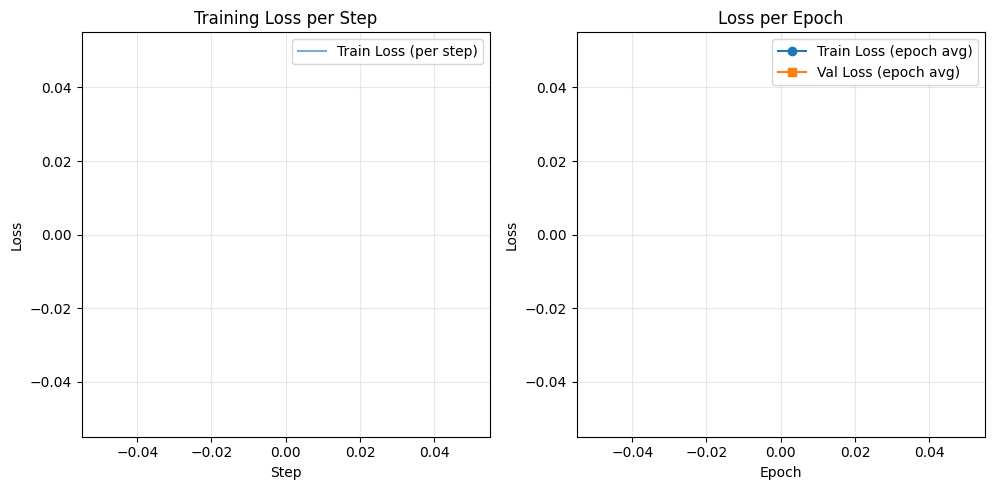

In [ ]:
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.plot(step_train_losses, label="Train Loss (per step)", alpha=0.6)
plt.title("Training Loss per Step")
plt.xlabel("Step")
plt.ylabel("Loss")
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 3, 2)
plt.plot(train_losses, label="Train Loss (epoch avg)", marker='o')
plt.plot(val_losses, label="Val Loss (epoch avg)", marker='s')
plt.title("Loss per Epoch")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
import torch
import numpy as np

# Generate text using the model
# Note: For streaming dataset, we can't index directly, so we'll generate from scratch
model.eval()

# Generate a sample from validation set
val_iter = iter(val_loader)
sample_batch = next(val_iter)
input_ids = sample_batch[0:1, :].to(device)  # Take first sample, shape (1, T)

# Crop to reasonable length
max_len_generation = 100
input_ids = input_ids[:, :max_len_generation]
seq_len = input_ids.shape[1]

# Initialize sequences with the first (true) token
start_token_id = input_ids[0, 0].item()
forced_generated_ids = [start_token_id]
free_generated_ids = [start_token_id]
stateFree = model.get_init_state(1, device)
stateForced = model.get_init_state(1, device)

# Generate text
with torch.no_grad():
    for t in tqdm(range(1, seq_len), desc="Generating"):
        # Teacher forcing: feed ONLY the next token (not entire prefix)
        next_token = input_ids[:, t:t+1]  # shape (1, 1) - single token
        logits_tf, stateForced = model(next_token, stateForced)
        # logits_tf is already (1, vocab) for single-token inference
        next_id_tf = torch.argmax(logits_tf, dim=-1)
        forced_generated_ids.append(next_id_tf.item())

        # Free generation: feed ONLY the last generated token
        next_token_free = torch.tensor(
            [[free_generated_ids[-1]]], dtype=torch.long, device=device
        )  # shape (1, 1)
        logits_free, stateFree = model(next_token_free, stateFree)
        # logits_free is already (1, vocab) for single-token inference
        next_id_free = torch.argmax(logits_free, dim=-1)
        free_generated_ids.append(next_id_free.item())

print("Original Text:")
print(tokenizer.decode(input_ids[0].cpu().numpy(), skip_special_tokens=True))
print("\nTeacher Forcing Generation:")
print(tokenizer.decode(forced_generated_ids, skip_special_tokens=True))
print("\nFree Generation:")
print(tokenizer.decode(free_generated_ids, skip_special_tokens=True))

Generating: 100%|██████████| 99/99 [00:01<00:00, 82.46it/s] 

Original Text:
One day, a little girl named Lily found a needle in her room. She knew it was difficult to play with it because it was sharp. Lily wanted to share the needle with her mom, so she could sew a button on her shirt.

Lily went to her mom and said, "Mom, I found this needle. Can you share it with me and sew my shirt?" Her mom smiled and said, "Yes, Lily, we can share the needle and fix your shirt."

Teacher Forcing Generation:
One, a little girl named Lily went a big. the mom. She was a to very. the with his... very. He was to play the park. his mom. and mom,.. mom. his mom. He had liked, and to the the. the. a.. a. his her. He,,,, his his his was the,. They and. his. her her to her. her walking.. park. his his. her.

Free Generation:
One day, a little girl named Lily went to the park. She had a big, big, a big, little girl. She was very excited. She was very excited. He was very excited. He was very excited. He was very excited. He was very excited. He was very excited. He w

In [ ]:
!pip install evaluate rouge_score nltk --quiet

In [ ]:
import evaluate
import nltk
from nltk.translate.bleu_score import sentence_bleu

model.eval()

rouge = evaluate.load("rouge")
bleu_scores = []

# Evaluate on a subset of validation data
NUM_EVAL_SAMPLES = 200
val_iter = iter(val_loader)

for eval_idx in tqdm(range(NUM_EVAL_SAMPLES), desc="Evaluating"):
    try:
        sample_batch = next(val_iter)
    except StopIteration:
        # Ran out of validation data
        NUM_EVAL_SAMPLES = eval_idx
        break

    # Take first sample from batch
    input_ids = sample_batch[0:1, :].to(device)  # (1, T)
    seq_len = input_ids.shape[1]

    # Free generation: first token is true, then model feeds itself
    start_token_id = input_ids[0, 0].item()
    generated_ids = [start_token_id]

    with torch.no_grad():
        for t in range(1, seq_len):
            prefix = torch.tensor(
                generated_ids, dtype=torch.long, device=device
            ).unsqueeze(0)  # shape (1, t)
            logits_seq = model(prefix)  # forward() for inference
            next_logits = logits_seq[:, -1, :]  # (1, vocab)
            next_token = torch.argmax(next_logits, dim=-1)  # (1,)
            generated_ids.append(next_token.item())

    reference = tokenizer.decode(input_ids[0].cpu().numpy(), skip_special_tokens=True)
    candidate = tokenizer.decode(generated_ids, skip_special_tokens=True)

    # Compute BLEU score
    reference_tokens = reference.split()
    candidate_tokens = candidate.split()
    bleu_score = sentence_bleu([reference_tokens], candidate_tokens, weights=(0.5, 0.5))
    bleu_scores.append(bleu_score)

    # Update ROUGE
    rouge.add_batch(predictions=[candidate], references=[reference])

results = rouge.compute()
avg_bleu = np.mean(bleu_scores)
print(f"ROUGE Scores: {results}")
print(f"Average BLEU Score: {avg_bleu:.4f}")